## Dataset Overview

In [2]:
import os
import pandas as pd

base_path = "/kaggle/input/datasets/abutalhadmaniyar/last-task/data"

data = []

# loop through each subfolder
for folder in os.listdir(base_path):
    folder_path = os.path.join(base_path, folder)

    if not os.path.isdir(folder_path):
        continue

    good_path = os.path.join(folder_path, "good")
    bad_path = os.path.join(folder_path, "bad")

    # count only .png files
    good_count = 0
    bad_count = 0

    if os.path.exists(good_path):
        good_count = len([f for f in os.listdir(good_path) if f.endswith(".png")])

    if os.path.exists(bad_path):
        bad_count = len([f for f in os.listdir(bad_path) if f.endswith(".png")])

    data.append({
        "Object": folder,
        "good_png_count": good_count,
        "bad_png_count": bad_count,
        "total_png": good_count + bad_count
    })

# create DataFrame
df_counts = pd.DataFrame(data)

# display
df_counts

,Object,good_png_count,bad_png_count,total_png
0,wood,266,60,326
1,metal_nut,242,70,312
2,capsule,242,109,351
3,KolektorSDD,746,52,798
4,railway,105,94,199
5,hazelnut,431,70,501
6,carpet,308,89,397
7,mutou,867,1838,2705
8,pill,293,141,434
9,grid,285,57,342


In [3]:
from itertools import combinations

base_path = "/kaggle/input/datasets/abutalhadmaniyar/last-task/data"

pairs = []

# loop through each folder (folder1, folder2, etc.)
for folder in os.listdir(base_path):
    folder_path = os.path.join(base_path, folder)

    if not os.path.isdir(folder_path):
        continue

    good_path = os.path.join(folder_path, "good")
    bad_path = os.path.join(folder_path, "bad")

    # get only PNG images
    good_images = [os.path.join(good_path, f)
                   for f in os.listdir(good_path) if f.endswith(".png")]

    bad_images = [os.path.join(bad_path, f)
                  for f in os.listdir(bad_path) if f.endswith(".png")]

    # 🔹 good-good pairs
    for img1, img2 in combinations(good_images, 2):
        pairs.append({
            "img1": img1,
            "img2": img2,
            "label": 0
        })

    # 🔹 good-bad pairs
    for g in good_images:
        for b in bad_images:
            pairs.append({
                "img1": g,
                "img2": b,
                "label": 1
            })

# create DataFrame
df = pd.DataFrame(pairs)

# preview
df.head()

,img1,img2,label
0,/kaggle/input/datasets/abutalhadmaniyar/last-t...,/kaggle/input/datasets/abutalhadmaniyar/last-t...,0
1,/kaggle/input/datasets/abutalhadmaniyar/last-t...,/kaggle/input/datasets/abutalhadmaniyar/last-t...,0
2,/kaggle/input/datasets/abutalhadmaniyar/last-t...,/kaggle/input/datasets/abutalhadmaniyar/last-t...,0
3,/kaggle/input/datasets/abutalhadmaniyar/last-t...,/kaggle/input/datasets/abutalhadmaniyar/last-t...,0
4,/kaggle/input/datasets/abutalhadmaniyar/last-t...,/kaggle/input/datasets/abutalhadmaniyar/last-t...,0


In [4]:
df["label"].value_counts()

label
0    21106585
1     5182622
Name: count, dtype: int64

In [11]:
df_counts['good_png_count'] * df_counts['good_png_count']

0        70756
1        58564
2        58564
3       556516
4        11025
5       185761
6        94864
7       751689
8        85849
9        81225
10       73984
11      906304
12      131044
13       69169
14        1521
15    38875225
16       76729
17        5184
18       52441
19       79524
Name: good_png_count, dtype: int64

In [12]:
df_counts['good_png_count'] * df_counts['bad_png_count']

0       15960
1       16940
2       26378
3       38792
4        9870
5       30170
6       27412
7     1593546
8       41313
9       16245
10      32368
11     373184
12     154212
13      22092
14       3900
15    2712225
16      25484
17       2160
18      14427
19      25944
dtype: int64

## Creating a model

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from PIL import Image, UnidentifiedImageError
import torchvision.transforms as transforms

### Load Dataset

In [6]:
class SiameseDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __getitem__(self, index):

        img1_rel = self.df.iloc[index, 0]
        img2_rel = self.df.iloc[index, 1]

        img1_path = img1_rel
        img2_path = img2_rel

        try:
          img1 = Image.open(img1_path).convert("RGB")
          img2 = Image.open(img2_path).convert("RGB")
        except UnidentifiedImageError:
          # pick another sample if image is broken
          return self.__getitem__((index + 1) % len(self.df))

        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)

        label = torch.tensor(self.df.iloc[index, 2], dtype=torch.float32).unsqueeze(0)

        return img1, img2, label

    def __len__(self):
        return len(self.df)

In [7]:
transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.ToTensor()
])

In [8]:
from sklearn.model_selection import train_test_split

# 98% train, 1% val, 1% test
train_df, temp_df = train_test_split(
    df, test_size=0.02, random_state=42, stratify=df["label"]
)

val_df, test_df = train_test_split(
    temp_df, test_size=0.5, random_state=42, stratify=temp_df["label"]
)

batch_size = 32

# Static Datasets/Loaders for Validation and Testing
val_dataset = SiameseDataset(val_df, transform)
test_dataset = SiameseDataset(test_df, transform)

val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

print(f"Total Training Pool: {len(train_df)}")
print(f"Validation size    : {len(val_df)}")
print(f"Test size          : {len(test_df)}")

Total Training Pool: 25763422
Validation size    : 262892
Test size          : 262893


## Model Defining

In [9]:
class SiameseNetwork(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            # Block 1
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 4
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.pool = nn.AdaptiveAvgPool2d((1,1))

        self.embedding = nn.Sequential(
            nn.Linear(256,256),
            nn.ReLU(),
            nn.Linear(256,128),
            nn.ReLU()
        )

        self.classifier = nn.Sequential(
            nn.Linear(384,128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Linear(64,1)
        )

    def forward_once(self,x):

        x = self.features(x)
        x = self.pool(x)
        x = x.view(x.size(0),-1)

        embedding = self.embedding(x)

        return embedding


    def forward(self,x1,x2):

        e1 = self.forward_once(x1)
        e2 = self.forward_once(x2)

        #diff = torch.abs(e1 - e2)
        x = torch.cat([e1, e2, torch.abs(e1-e2)], dim=1)
        out = self.classifier(x)

        return out

## Training Setup

In [10]:
def train_one_epoch(loader):

    model.train()
    running_loss = 0

    for img1,img2,label in loader:

        img1 = img1.to(device)
        img2 = img2.to(device)
        label = label.to(device)
        optimizer.zero_grad()
        logits = model(img1,img2)
        loss = criterion(logits,label)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    return running_loss/len(loader)

In [11]:
def evaluate(loader):

    model.eval()
    total_loss = 0

    with torch.no_grad():

        for img1,img2,label in loader:

            img1 = img1.to(device)
            img2 = img2.to(device)
            label = label.to(device)
            logits = model(img1,img2)
            loss = criterion(logits,label)
            total_loss += loss.item()

    return total_loss/len(loader)

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SiameseNetwork().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(),lr=1e-3)

In [13]:
model.load_state_dict(torch.load('/kaggle/input/models/abutalhadmaniyar/final-model/pytorch/default/1/obj20_model_epoch_5.pth'))

<All keys matched successfully>

In [ ]:
epochs = 5
sample_size = 100000

for epoch in range(epochs):
    # Every 3 epochs (0, 3, 6...), pick a new random 100k sample from the 98% pool
    if epoch % 3 == 0:
        print(f"\n--- Resampling {sample_size} rows for the next 3 epochs ---")
        sampled_train_df = train_df.sample(n=sample_size, random_state=epoch) # random_state changes each time
        
        # Create new dataset and loader for this specific sample
        current_train_dataset = SiameseDataset(sampled_train_df, transform)
        train_loader = DataLoader(
            current_train_dataset, 
            batch_size=batch_size, 
            shuffle=True, 
            num_workers=4, 
            pin_memory=True
        )

    # Standard Training Logic
    train_loss = train_one_epoch(train_loader)
    val_loss = evaluate(val_loader)
    
    # Save model
    model_path = f"obj20_model_epoch_{epoch+1}.pth"
    torch.save(model.state_dict(), model_path)
    
    print(f"Epoch {epoch+16}/{epochs+15} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")


--- Resampling 100000 rows for the next 3 epochs ---
Epoch 16/20 | Train Loss: 0.0872 | Val Loss: 0.0819
Epoch 17/20 | Train Loss: 0.0793 | Val Loss: 0.0713
Epoch 18/20 | Train Loss: 0.0724 | Val Loss: 0.0656

--- Resampling 100000 rows for the next 3 epochs ---
Epoch 19/20 | Train Loss: 0.0675 | Val Loss: 0.0628


--- Resampling 100000 rows for the next 3 epochs ---
Epoch 1/20 | Train Loss: 0.2827 | Val Loss: 0.2165
Epoch 2/20 | Train Loss: 0.2123 | Val Loss: 0.2591
Epoch 3/20 | Train Loss: 0.1807 | Val Loss: 0.1488

--- Resampling 100000 rows for the next 3 epochs ---
Epoch 4/20 | Train Loss: 0.1416 | Val Loss: 0.1123
Epoch 5/20 | Train Loss: 0.1132 | Val Loss: 0.0972
Epoch 6/20 | Train Loss: 0.1044 | Val Loss: 0.0983

--- Resampling 100000 rows for the next 3 epochs ---
Epoch 7/20 | Train Loss: 0.1024 | Val Loss: 0.0959
Epoch 8/20 | Train Loss: 0.0991 | Val Loss: 0.0946
Epoch 9/20 | Train Loss: 0.0995 | Val Loss: 0.0943

--- Resampling 100000 rows for the next 3 epochs ---
Epoch 10/20 | Train Loss: 0.0970 | Val Loss: 0.0892
Epoch 11/20 | Train Loss: 0.0958 | Val Loss: 0.0907
Epoch 12/20 | Train Loss: 0.0957 | Val Loss: 0.0888

--- Resampling 100000 rows for the next 3 epochs ---
Epoch 13/20 | Train Loss: 0.0925 | Val Loss: 0.1077
Epoch 14/20 | Train Loss: 0.0919 | Val Loss: 0.0964
Epoch 15/20 | Train Loss: 0.0897 | Val Loss: 0.0858


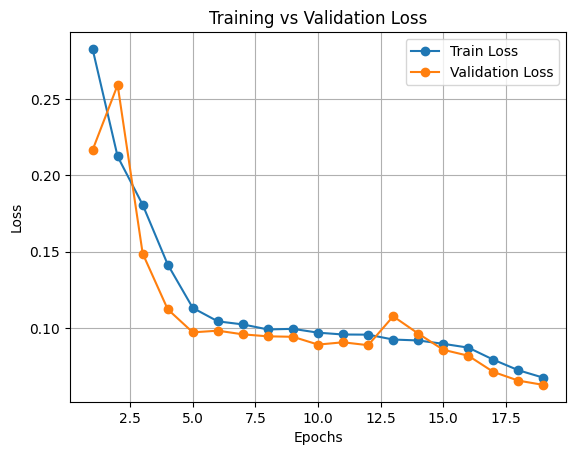

In [18]:
import matplotlib.pyplot as plt

# Epochs
epochs = list(range(1, 20))

# Train and Validation Loss (from your logs)
train_loss = [
    0.2827, 0.2123, 0.1807,
    0.1416, 0.1132, 0.1044,
    0.1024, 0.0991, 0.0995,
    0.0970, 0.0958, 0.0957,
    0.0925, 0.0919, 0.0897,
    0.0872, 0.0793, 0.0724,
    0.0675
]

val_loss = [
    0.2165, 0.2591, 0.1488,
    0.1123, 0.0972, 0.0983,
    0.0959, 0.0946, 0.0943,
    0.0892, 0.0907, 0.0888,
    0.1077, 0.0964, 0.0858,
    0.0819, 0.0713, 0.0656,
    0.0628
]

# Plot
plt.figure()
plt.plot(epochs, train_loss, marker='o', label='Train Loss')
plt.plot(epochs, val_loss, marker='o', label='Validation Loss')

# Labels and title
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')

# Legend
plt.legend()

# Grid
plt.grid()

# Show plot
plt.show()

### Evaluating the Model with Metrics

In [14]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [15]:
def get_predictions(loader, threshold=0.5):

    model.eval()

    all_labels = []
    all_preds = []

    with torch.no_grad():

        for img1, img2, label in loader:

            img1 = img1.to(device)
            img2 = img2.to(device)

            logits = model(img1, img2)
            probs = torch.sigmoid(logits)

            preds = (probs > threshold).float()

            all_labels.extend(label.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    return all_labels, all_preds

In [16]:
y_true, y_pred = get_predictions(test_loader)

precision = precision_score(y_true, y_pred, pos_label=1)
recall = recall_score(y_true, y_pred, pos_label=1)
f1 = f1_score(y_true, y_pred, pos_label=1)

print("Precision:", precision)
print("Recall (label=1):", recall)
print("F1 Score:", f1)

print("\nConfusion Matrix")
print(confusion_matrix(y_true, y_pred))

Precision: 0.8985377556071741
Recall (label=1): 0.9105871456962588
F1 Score: 0.9045223241238536

Confusion Matrix
[[205737   5329]
 [  4634  47193]]


In [17]:
(205737+47193)/262893

0.9621024523285139